<a href="https://colab.research.google.com/github/DharankumarCS/fashion-mnist-atri/blob/main/notebooks/experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (60000, 28, 28)
Testing shape: (10000, 28, 28)


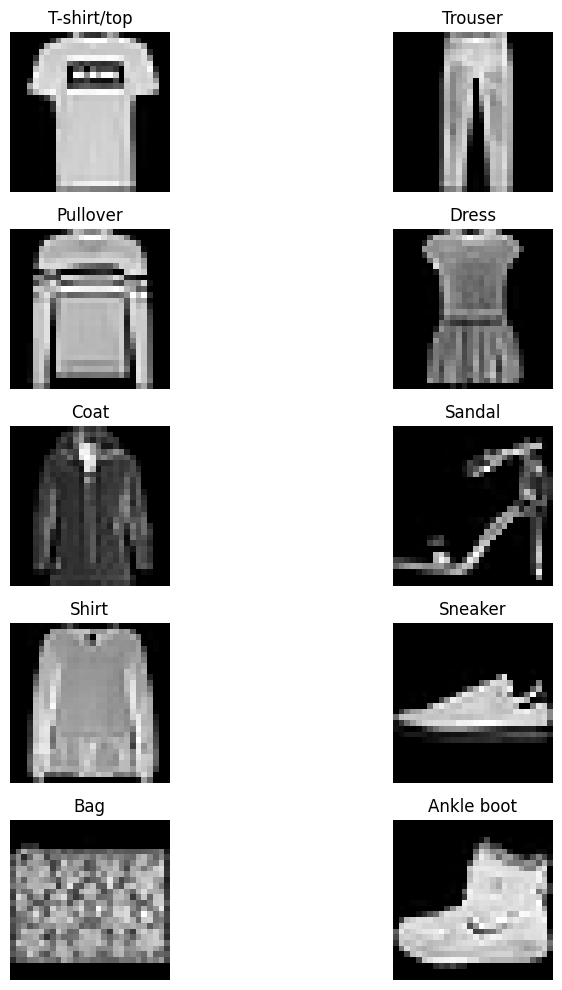

In [5]:
# Normalize data
X_train = X_train / 255.0
X_test = X_test / 255.0

# Fashion MNIST class names
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# Plot one image from each class
plt.figure(figsize=(10,10))

for i in range(10):

    index = np.where(y_train == i)[0][0]

    plt.subplot(5,2,i+1)
    plt.imshow(X_train[index], cmap='gray')
    plt.title(class_names[i])
    plt.axis('off')

plt.tight_layout()
plt.show()
#Question 1 completed

In [6]:
# Flatten 28x28 images into 784-dimensional vectors

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Flattened training shape:", X_train_flat.shape)
print("Flattened testing shape:", X_test_flat.shape)

Flattened training shape: (60000, 784)
Flattened testing shape: (10000, 784)


In [7]:
# One-hot encode labels

def one_hot_encode(labels, num_classes=10):

    one_hot = np.zeros((labels.size, num_classes))

    one_hot[np.arange(labels.size), labels] = 1

    return one_hot

y_train_encoded = one_hot_encode(y_train)
y_test_encoded = one_hot_encode(y_test)

print(y_train_encoded.shape)

(60000, 10)


In [8]:
# Create shuffled validation split

validation_split = 0.1

indices = np.random.permutation(len(X_train_flat))

X_train_shuffled = X_train_flat[indices]
Y_train_shuffled = y_train_encoded[indices]

split_index = int((1 - validation_split) * len(X_train_shuffled))

X_train_final = X_train_shuffled[:split_index]
Y_train_final = Y_train_shuffled[:split_index]

X_val = X_train_shuffled[split_index:]
Y_val = Y_train_shuffled[split_index:]

print("Training data shape:", X_train_final.shape)
print("Validation data shape:", X_val.shape)

Training data shape: (54000, 784)
Validation data shape: (6000, 784)


In [9]:
def initialize_parameters(input_size, hidden_layers,
                          output_size, init_type="xavier"):
    parameters = {}
    layer_sizes = [input_size] + hidden_layers + [output_size]

    for i in range(1, len(layer_sizes)):
        n_in  = layer_sizes[i-1]
        n_out = layer_sizes[i]

        if init_type == "xavier":
            scale = np.sqrt(2.0 / (n_in + n_out))
        else:
            scale = 0.01

        parameters[f'W{i}'] = np.random.randn(n_out, n_in) * scale
        parameters[f'b{i}'] = np.zeros((n_out, 1))

    return parameters

In [10]:
def get_activation(Z, activation="relu"):
    if activation == "relu":
        return relu(Z)
    elif activation == "sigmoid":
        return sigmoid(Z)
    elif activation == "tanh":
        return tanh(Z)



In [11]:
def forward_propagation(X, parameters, activation="relu"):
    cache = {}
    A = X.T
    num_layers = len(parameters) // 2

    for i in range(1, num_layers):
        W = parameters[f'W{i}']
        b = parameters[f'b{i}']
        Z = np.dot(W, A) + b
        A = get_activation(Z, activation)  # flexible!
        cache[f'Z{i}'] = Z
        cache[f'A{i}'] = A

    # Output layer always softmax
    W = parameters[f'W{num_layers}']
    b = parameters[f'b{num_layers}']
    Z = np.dot(W, A) + b
    A = softmax(Z)
    cache[f'Z{num_layers}'] = Z
    cache[f'A{num_layers}'] = A

    return A, cache

In [12]:
import numpy as np

# activation functions
def relu(Z):
    return np.maximum(0, Z)

def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

def tanh(Z):
    return np.tanh(Z)

def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)

# Test forward propagation
input_size = X_train_flat.shape[1]
output_size = y_train_encoded.shape[1]
hidden_layers = [128, 64] # Eg hidden layer sizes

parameters = initialize_parameters(input_size, hidden_layers, output_size)

output, cache = forward_propagation(X_train_flat[:5], parameters)

print("Output shape:", output.shape)
#Question 2 completed

Output shape: (10, 5)


In [13]:
# Cross entropy loss with L2 regularization

def compute_loss(Y, Y_hat,
                 parameters=None,
                 weight_decay=0):

    m = Y.shape[0]

    ce_loss = -np.sum(
        Y.T * np.log(Y_hat + 1e-8)
    ) / m

    l2_loss = 0

    if parameters is not None and weight_decay > 0:

        num_layers = len(parameters) // 2

        for i in range(1, num_layers + 1):

            l2_loss += np.sum(
                parameters[f'W{i}'] ** 2
            )

        l2_loss = (
            weight_decay / (2 * m)
        ) * l2_loss

    return ce_loss + l2_loss

In [14]:
# Test loss function

Y_sample = y_train_encoded[:5]

loss = compute_loss(Y_sample, output)

print("Loss:", loss)

Loss: 2.41655742519838


In [15]:
# ReLU derivative

def relu_derivative(Z):

    return (Z > 0).astype(float)

In [16]:
# Activation derivatives

def sigmoid_derivative(Z):

    s = sigmoid(Z)

    return s * (1 - s)

def tanh_derivative(Z):

    return 1 - np.tanh(Z)**2

def get_activation_derivative(Z, activation="relu"):

    if activation == "relu":
        return relu_derivative(Z)

    elif activation == "sigmoid":
        return sigmoid_derivative(Z)

    elif activation == "tanh":
        return tanh_derivative(Z)

In [17]:
# Backpropagation

def backward_propagation(
    X,
    Y,
    parameters,
    cache,
    activation="relu"
):

    gradients = {}

    m = X.shape[0]

    num_layers = len(parameters) // 2

    A_final = cache[f'A{num_layers}']

    # Output layer gradient
    dZ = A_final - Y.T

    for i in reversed(range(1, num_layers + 1)):

        A_prev = X.T if i == 1 else cache[f'A{i-1}']

        gradients[f'dW{i}'] = (1 / m) * np.dot(dZ, A_prev.T)
        gradients[f'db{i}'] = (1 / m) * np.sum(dZ, axis=1, keepdims=True)

        if i > 1:

            W = parameters[f'W{i}']
            Z_prev = cache[f'Z{i-1}']

            dA_prev = np.dot(W.T, dZ)

            dZ = dA_prev * get_activation_derivative(
    Z_prev,
    activation
)

    return gradients

In [18]:
# Test backpropagation

gradients = backward_propagation(
    X_train_flat[:5],
    y_train_encoded[:5],
    parameters,
    cache
)

print(gradients.keys())

dict_keys(['dW3', 'db3', 'dW2', 'db2', 'dW1', 'db1'])


In [19]:
# Update parameters and SGD
def update_parameters(parameters, gradients, learning_rate):
    num_layers = len(parameters) // 2

    for i in range(1, num_layers + 1):
        parameters[f'W{i}'] = parameters[f'W{i}'] - learning_rate * gradients[f'dW{i}']
        parameters[f'b{i}'] = parameters[f'b{i}'] - learning_rate * gradients[f'db{i}']

    return parameters

learning_rate = 0.01 # Define a learning rate

updated_parameters = update_parameters(parameters, gradients, learning_rate)

print("Parameters updated for W1 (first few values):\n", updated_parameters['W1'][:2, :2])

Parameters updated for W1 (first few values):
 [[-0.05081623  0.04654994]
 [ 0.06240896 -0.10371598]]


In [20]:
# Initialize velocity for Momentum

def initialize_velocity(parameters):

    velocity = {}

    num_layers = len(parameters) // 2

    for i in range(1, num_layers + 1):

        velocity[f'dW{i}'] = np.zeros_like(parameters[f'W{i}'])
        velocity[f'db{i}'] = np.zeros_like(parameters[f'b{i}'])

    return velocity

In [21]:
# Momentum optimizer

def update_parameters_momentum(parameters, gradients,
                               velocity, learning_rate,
                               beta=0.9):

    num_layers = len(parameters) // 2

    for i in range(1, num_layers + 1):

        # Update velocity
        velocity[f'dW{i}'] = (
            beta * velocity[f'dW{i}']
            + (1 - beta) * gradients[f'dW{i}']
        )

        velocity[f'db{i}'] = (
            beta * velocity[f'db{i}']
            + (1 - beta) * gradients[f'db{i}']
        )

        # Update parameters
        parameters[f'W{i}'] -= learning_rate * velocity[f'dW{i}']

        parameters[f'b{i}'] -= learning_rate * velocity[f'db{i}']

    return parameters, velocity

In [22]:
# Test Momentum optimizer

velocity = initialize_velocity(parameters)

parameters, velocity = update_parameters_momentum(
    parameters,
    gradients,
    velocity,
    learning_rate=0.01
)

print("Momentum update completed")

Momentum update completed


In [23]:
# Nesterov Accelerated Gradient (NAG)

def update_parameters_nag(parameters, gradients,
                          velocity, learning_rate,
                          beta=0.9):

    num_layers = len(parameters) // 2

    for i in range(1, num_layers + 1):

        # Update velocity
        velocity[f'dW{i}'] = (
            beta * velocity[f'dW{i}']
            + gradients[f'dW{i}']
        )

        velocity[f'db{i}'] = (
            beta * velocity[f'db{i}']
            + gradients[f'db{i}']
        )

        # NAG parameter update
        parameters[f'W{i}'] -= learning_rate * (
        beta * velocity[f'dW{i}']
        + gradients[f'dW{i}']
    )
        parameters[f'b{i}'] -= learning_rate * (
        beta * velocity[f'db{i}']
        + gradients[f'db{i}']
    )

    return parameters, velocity

In [24]:
# Test NAG optimizer

velocity = initialize_velocity(parameters)

parameters, velocity = update_parameters_nag(
    parameters,
    gradients,
    velocity,
    learning_rate=0.01
)

print("NAG update completed")

NAG update completed


In [25]:
# Initialize RMSProp cache

def initialize_rmsprop(parameters):

    cache = {}

    num_layers = len(parameters) // 2

    for i in range(1, num_layers + 1):

        cache[f'dW{i}'] = np.zeros_like(parameters[f'W{i}'])
        cache[f'db{i}'] = np.zeros_like(parameters[f'b{i}'])

    return cache

In [26]:
# RMSProp optimizer

def update_parameters_rmsprop(parameters, gradients,
                              cache, learning_rate,
                              beta=0.9, epsilon=1e-8):

    num_layers = len(parameters) // 2

    for i in range(1, num_layers + 1):

        # Update cache
        cache[f'dW{i}'] = (
            beta * cache[f'dW{i}']
            + (1 - beta) * (gradients[f'dW{i}'] ** 2)
        )

        cache[f'db{i}'] = (
            beta * cache[f'db{i}']
            + (1 - beta) * (gradients[f'db{i}'] ** 2)
        )

        # Update parameters
        parameters[f'W{i}'] -= (
            learning_rate
            * gradients[f'dW{i}']
            / (np.sqrt(cache[f'dW{i}']) + epsilon)
        )

        parameters[f'b{i}'] -= (
            learning_rate
            * gradients[f'db{i}']
            / (np.sqrt(cache[f'db{i}']) + epsilon)
        )

    return parameters, cache

In [ ]:
# Test RMSProp optimizer

cache = initialize_rmsprop(parameters)

parameters, cache = update_parameters_rmsprop(
    parameters,
    gradients,
    cache,
    learning_rate=0.001
)

print("RMSProp update completed")

RMSProp update completed


In [27]:
# Initialize Adam variables

def initialize_adam(parameters):

    v = {}
    s = {}

    num_layers = len(parameters) // 2

    for i in range(1, num_layers + 1):

        v[f'dW{i}'] = np.zeros_like(parameters[f'W{i}'])
        v[f'db{i}'] = np.zeros_like(parameters[f'b{i}'])

        s[f'dW{i}'] = np.zeros_like(parameters[f'W{i}'])
        s[f'db{i}'] = np.zeros_like(parameters[f'b{i}'])

    return v, s

In [28]:
# Adam optimizer

def update_parameters_adam(parameters, gradients,
                           v, s, t,
                           learning_rate=0.001,
                           beta1=0.9,
                           beta2=0.999,
                           epsilon=1e-8):

    num_layers = len(parameters) // 2

    for i in range(1, num_layers + 1):

        # Momentum
        v[f'dW{i}'] = (
            beta1 * v[f'dW{i}']
            + (1 - beta1) * gradients[f'dW{i}']
        )

        v[f'db{i}'] = (
            beta1 * v[f'db{i}']
            + (1 - beta1) * gradients[f'db{i}']
        )

        # RMSProp
        s[f'dW{i}'] = (
            beta2 * s[f'dW{i}']
            + (1 - beta2) * (gradients[f'dW{i}'] ** 2)
        )

        s[f'db{i}'] = (
            beta2 * s[f'db{i}']
            + (1 - beta2) * (gradients[f'db{i}'] ** 2)
        )

        # Bias correction
        v_corrected_dW = v[f'dW{i}'] / (1 - beta1**t)
        v_corrected_db = v[f'db{i}'] / (1 - beta1**t)

        s_corrected_dW = s[f'dW{i}'] / (1 - beta2**t)
        s_corrected_db = s[f'db{i}'] / (1 - beta2**t)

        # Parameter update
        parameters[f'W{i}'] -= (
            learning_rate
            * v_corrected_dW
            / (np.sqrt(s_corrected_dW) + epsilon)
        )

        parameters[f'b{i}'] -= (
            learning_rate
            * v_corrected_db
            / (np.sqrt(s_corrected_db) + epsilon)
        )

    return parameters, v, s

In [29]:
# Test Adam optimizer

v, s = initialize_adam(parameters)

parameters, v, s = update_parameters_adam(
    parameters,
    gradients,
    v,
    s,
    t=1
)

print("Adam update completed")

Adam update completed


In [30]:
# Nadam optimizer

def update_parameters_nadam(parameters, gradients,
                            v, s, t,
                            learning_rate=0.001,
                            beta1=0.9,
                            beta2=0.999,
                            epsilon=1e-8):

    num_layers = len(parameters) // 2

    for i in range(1, num_layers + 1):

        # Update momentum
        v[f'dW{i}'] = (
            beta1 * v[f'dW{i}']
            + (1 - beta1) * gradients[f'dW{i}']
        )

        v[f'db{i}'] = (
            beta1 * v[f'db{i}']
            + (1 - beta1) * gradients[f'db{i}']
        )

        # Update RMSProp cache
        s[f'dW{i}'] = (
            beta2 * s[f'dW{i}']
            + (1 - beta2) * (gradients[f'dW{i}'] ** 2)
        )

        s[f'db{i}'] = (
            beta2 * s[f'db{i}']
            + (1 - beta2) * (gradients[f'db{i}'] ** 2)
        )

        # Bias correction
        v_corrected_dW = (
            beta1 * v[f'dW{i}']
            + ((1 - beta1) * gradients[f'dW{i}'])
        ) / (1 - beta1**t)

        v_corrected_db = (
            beta1 * v[f'db{i}']
            + ((1 - beta1) * gradients[f'db{i}'])
        ) / (1 - beta1**t)

        s_corrected_dW = s[f'dW{i}'] / (1 - beta2**t)
        s_corrected_db = s[f'db{i}'] / (1 - beta2**t)

        # Update parameters
        parameters[f'W{i}'] -= (
            learning_rate
            * v_corrected_dW
            / (np.sqrt(s_corrected_dW) + epsilon)
        )

        parameters[f'b{i}'] -= (
            learning_rate
            * v_corrected_db
            / (np.sqrt(s_corrected_db) + epsilon)
        )

    return parameters, v, s

In [31]:
# Test Nadam optimizer

v, s = initialize_adam(parameters)

parameters, v, s = update_parameters_nadam(
    parameters,
    gradients,
    v,
    s,
    t=1
)

print("Nadam update completed")
#question 3 completed

Nadam update completed


In [32]:
# Accuracy function

def compute_accuracy(Y_true, Y_pred):

    true_labels = np.argmax(Y_true, axis=1)
    predicted_labels = np.argmax(Y_pred.T, axis=1)

    accuracy = np.mean(true_labels == predicted_labels)

    return accuracy

In [33]:
# Training loop

def train_network(X_train, Y_train,
                  parameters,
                  epochs=10,
                  learning_rate=0.01):

    for epoch in range(epochs):

        # Forward propagation
        output, cache = forward_propagation(
            X_train,
            parameters,
            activation="relu"
        )

        # Loss
        loss = compute_loss(Y_train, output)

        # Backpropagation
        gradients = backward_propagation(
            X_train,
            Y_train,
            parameters,
            cache
        )

        # SGD update
        parameters = update_parameters(
            parameters,
            gradients,
            learning_rate
        )

        # Accuracy
        accuracy = compute_accuracy(Y_train, output)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Loss: {loss:.4f} | "
            f"Accuracy: {accuracy:.4f}"
        )

    return parameters

In [34]:
# Train the neural network

trained_parameters = train_network(
    X_train_flat[:1000],
    y_train_encoded[:1000],
    parameters,
    epochs=5,
    learning_rate=0.01
)

Epoch 1/5 | Loss: 2.4367 | Accuracy: 0.1840
Epoch 2/5 | Loss: 2.3692 | Accuracy: 0.1780
Epoch 3/5 | Loss: 2.3182 | Accuracy: 0.1680
Epoch 4/5 | Loss: 2.2771 | Accuracy: 0.1670
Epoch 5/5 | Loss: 2.2431 | Accuracy: 0.1610


In [ ]:
import wandb

In [ ]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: dharankumarcs_27 (vaishalinir-ymc2022-chennai-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [35]:
# WandB sweep configuration

sweep_config = {

    'method': 'bayes',

    'metric': {
        'name': 'val_accuracy',
        'goal': 'maximize'
    },

    'parameters': {

        'epochs': {
            'values': [5, 10]
        },

        'hidden_layers': {
            'values': [3, 4, 5]
        },

        'hidden_size': {
            'values': [32, 64, 128]
        },

        'weight_decay': {
            'values': [0, 0.0005, 0.5]
        },

        'learning_rate': {
            'values': [1e-3, 1e-4]
        },

        'optimizer': {
            'values': [
                'sgd',
                'momentum',
                'nesterov',
                'rmsprop',
                'adam',
                'nadam'
            ]
        },

        'batch_size': {
            'values': [16, 32, 64]
        },

        'weight_init': {
            'values': ['random', 'xavier']
        },

        'activation': {
            'values': ['sigmoid', 'tanh', 'relu']
        }
    }
}

In [ ]:
# Create sweep

sweep_id = wandb.sweep(
    sweep_config,
    project="fashion-mnist-atri"
)

print("Sweep ID:", sweep_id)

Create sweep with ID: ujg9iq1g
Sweep URL: https://wandb.ai/vaishalinir-ymc2022-chennai-institute-of-technology/fashion-mnist-atri/sweeps/ujg9iq1g
Sweep ID: ujg9iq1g


In [36]:
def train_wandb():

    wandb.init()
    config = wandb.config
    wandb.run.name = f"hl_{config.hidden_layers}_bs_{config.batch_size}_ac_{config.activation}_opt_{config.optimizer}"


    hidden_layers = [config.hidden_size] * config.hidden_layers

    parameters = initialize_parameters(
        input_size=784,
        hidden_layers=hidden_layers,
        output_size=10,
        init_type=config.weight_init
    )

    velocity = initialize_velocity(parameters)
    rms_cache = initialize_rmsprop(parameters)
    v, s = initialize_adam(parameters)

    for epoch in range(config.epochs):

        num_batches = len(X_train_final) // config.batch_size

        for batch_idx in range(num_batches):

            start = batch_idx * config.batch_size
            end   = start + config.batch_size

            X_batch = X_train_final[start:end]
            Y_batch = Y_train_final[start:end]

            output, cache = forward_propagation(
                X_batch, parameters,
                activation=config.activation
            )

            loss = compute_loss(
                Y_batch, output,
                parameters, config.weight_decay
            )

            gradients = backward_propagation(
                X_batch, Y_batch,
                parameters, cache,
                activation=config.activation
            )

            if config.optimizer == "sgd":
                parameters = update_parameters(
                    parameters, gradients, config.learning_rate
                )

            elif config.optimizer == "momentum":
                parameters, velocity = update_parameters_momentum(
                    parameters, gradients, velocity, config.learning_rate
                )

            elif config.optimizer == "nesterov":
                parameters, velocity = update_parameters_nag(
                    parameters, gradients, velocity, config.learning_rate
                )

            elif config.optimizer == "rmsprop":
                parameters, rms_cache = update_parameters_rmsprop(
                    parameters, gradients, rms_cache, config.learning_rate
                )

            elif config.optimizer == "adam":
                parameters, v, s = update_parameters_adam(
                    parameters, gradients, v, s,
                    t=epoch + 1,
                    learning_rate=config.learning_rate
                )

            elif config.optimizer == "nadam":
                parameters, v, s = update_parameters_nadam(
                    parameters, gradients, v, s,
                    t=epoch + 1,
                    learning_rate=config.learning_rate
                )

        # Epoch end - accuracy + validation
        accuracy = compute_accuracy(Y_batch, output)

        val_output, _ = forward_propagation(
            X_val, parameters,
            activation=config.activation
        )

        val_loss = compute_loss(
            Y_val, val_output,
            parameters, config.weight_decay
        )

        val_accuracy = compute_accuracy(Y_val, val_output)

        wandb.log({
            "epoch"       : epoch + 1,
            "loss"        : loss,
            "accuracy"    : accuracy,
            "val_loss"    : val_loss,
            "val_accuracy": val_accuracy
        })

        print(
            f"Epoch {epoch+1}/{config.epochs} | "
            f"Loss: {loss:.4f} | "
            f"Acc: {accuracy:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )

In [ ]:
# Start sweep agent

wandb.agent(sweep_id, function=train_wandb, count=50)

wandb: Agent Starting Run: n3noj5wz with config:
wandb: 	activation: relu
wandb: 	batch_size: 32
wandb: 	epochs: 5
wandb: 	hidden_layers: 5
wandb: 	hidden_size: 32
wandb: 	learning_rate: 0.001
wandb: 	optimizer: adam
wandb: 	weight_decay: 0.0005
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Epoch 1/5 | Loss: 0.5453 | Acc: 0.8438 | Val Acc: 0.8357
Epoch 2/5 | Loss: 0.4949 | Acc: 0.8438 | Val Acc: 0.8508
Epoch 3/5 | Loss: 0.4503 | Acc: 0.8750 | Val Acc: 0.8570
Epoch 4/5 | Loss: 0.4305 | Acc: 0.9062 | Val Acc: 0.8595
Epoch 5/5 | Loss: 0.4085 | Acc: 0.9062 | Val Acc: 0.8623


accuracy,▁▁▅██
epoch,▁▃▅▆█
loss,█▅▃▂▁
val_accuracy,▁▅▇▇█
val_loss,█▄▃▂▁
accuracy,0.90625
epoch,5
loss,0.40853
val_accuracy,0.86233
val_loss,0.38294


wandb: Agent Starting Run: hezp2gc9 with config:
wandb: 	activation: tanh
wandb: 	batch_size: 16
wandb: 	epochs: 5
wandb: 	hidden_layers: 4
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	optimizer: sgd
wandb: 	weight_decay: 0.0005
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Epoch 1/5 | Loss: 0.7563 | Acc: 0.7500 | Val Acc: 0.7618
Epoch 2/5 | Loss: 0.6968 | Acc: 0.7500 | Val Acc: 0.7980
Epoch 3/5 | Loss: 0.6963 | Acc: 0.7500 | Val Acc: 0.8153
Epoch 4/5 | Loss: 0.7051 | Acc: 0.7500 | Val Acc: 0.8258
Epoch 5/5 | Loss: 0.7127 | Acc: 0.7500 | Val Acc: 0.8327


...

Epoch 1/10 | Loss: 0.3761 | Acc: 0.8281 | Val Acc: 0.8527
Epoch 2/10 | Loss: 0.3205 | Acc: 0.8594 | Val Acc: 0.8593
Epoch 3/10 | Loss: 0.3015 | Acc: 0.8594 | Val Acc: 0.8610
Epoch 4/10 | Loss: 0.2876 | Acc: 0.8750 | Val Acc: 0.8647
Epoch 5/10 | Loss: 0.2758 | Acc: 0.9062 | Val Acc: 0.8678
Epoch 6/10 | Loss: 0.2598 | Acc: 0.9062 | Val Acc: 0.8693
Epoch 7/10 | Loss: 0.2438 | Acc: 0.9375 | Val Acc: 0.8707
Epoch 8/10 | Loss: 0.2319 | Acc: 0.9375 | Val Acc: 0.8727
Epoch 9/10 | Loss: 0.2235 | Acc: 0.9375 | Val Acc: 0.8747
Epoch 10/10 | Loss: 0.2177 | Acc: 0.9375 | Val Acc: 0.8738


accuracy,▁▃▃▄▆▆████
epoch,▁▂▃▃▄▅▆▆▇█
loss,█▆▅▄▄▃▂▂▁▁
val_accuracy,▁▃▄▅▆▆▇▇██
val_loss,█▄▃▂▂▁▁▁▁▁
accuracy,0.9375
epoch,10
loss,0.2177
val_accuracy,0.87383
val_loss,0.35154


wandb: Agent Starting Run: 3xtfc85i with config:
wandb: 	activation: relu
wandb: 	batch_size: 64
wandb: 	epochs: 5
wandb: 	hidden_layers: 5
wandb: 	hidden_size: 64
wandb: 	learning_rate: 0.001
wandb: 	optimizer: nadam
wandb: 	weight_decay: 0
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Epoch 1/5 | Loss: 0.3827 | Acc: 0.8594 | Val Acc: 0.8453
Epoch 2/5 | Loss: 0.3213 | Acc: 0.8750 | Val Acc: 0.8563
Epoch 3/5 | Loss: 0.2983 | Acc: 0.8750 | Val Acc: 0.8650
Epoch 4/5 | Loss: 0.2923 | Acc: 0.8906 | Val Acc: 0.8690
Epoch 5/5 | Loss: 0.2926 | Acc: 0.8906 | Val Acc: 0.8687


accuracy,▁▅▅██
epoch,▁▃▅▆█
loss,█▃▁▁▁
val_accuracy,▁▄▇██
val_loss,█▅▃▂▁
accuracy,0.89062
epoch,5
loss,0.29258
val_accuracy,0.86867
val_loss,0.35061


Training best model for confusion matrix...
Epoch 1/10 completed
Epoch 2/10 completed
Epoch 3/10 completed
Epoch 4/10 completed
Epoch 5/10 completed
Epoch 6/10 completed
Epoch 7/10 completed
Epoch 8/10 completed
Epoch 9/10 completed
Epoch 10/10 completed

Test Accuracy: 87.68%


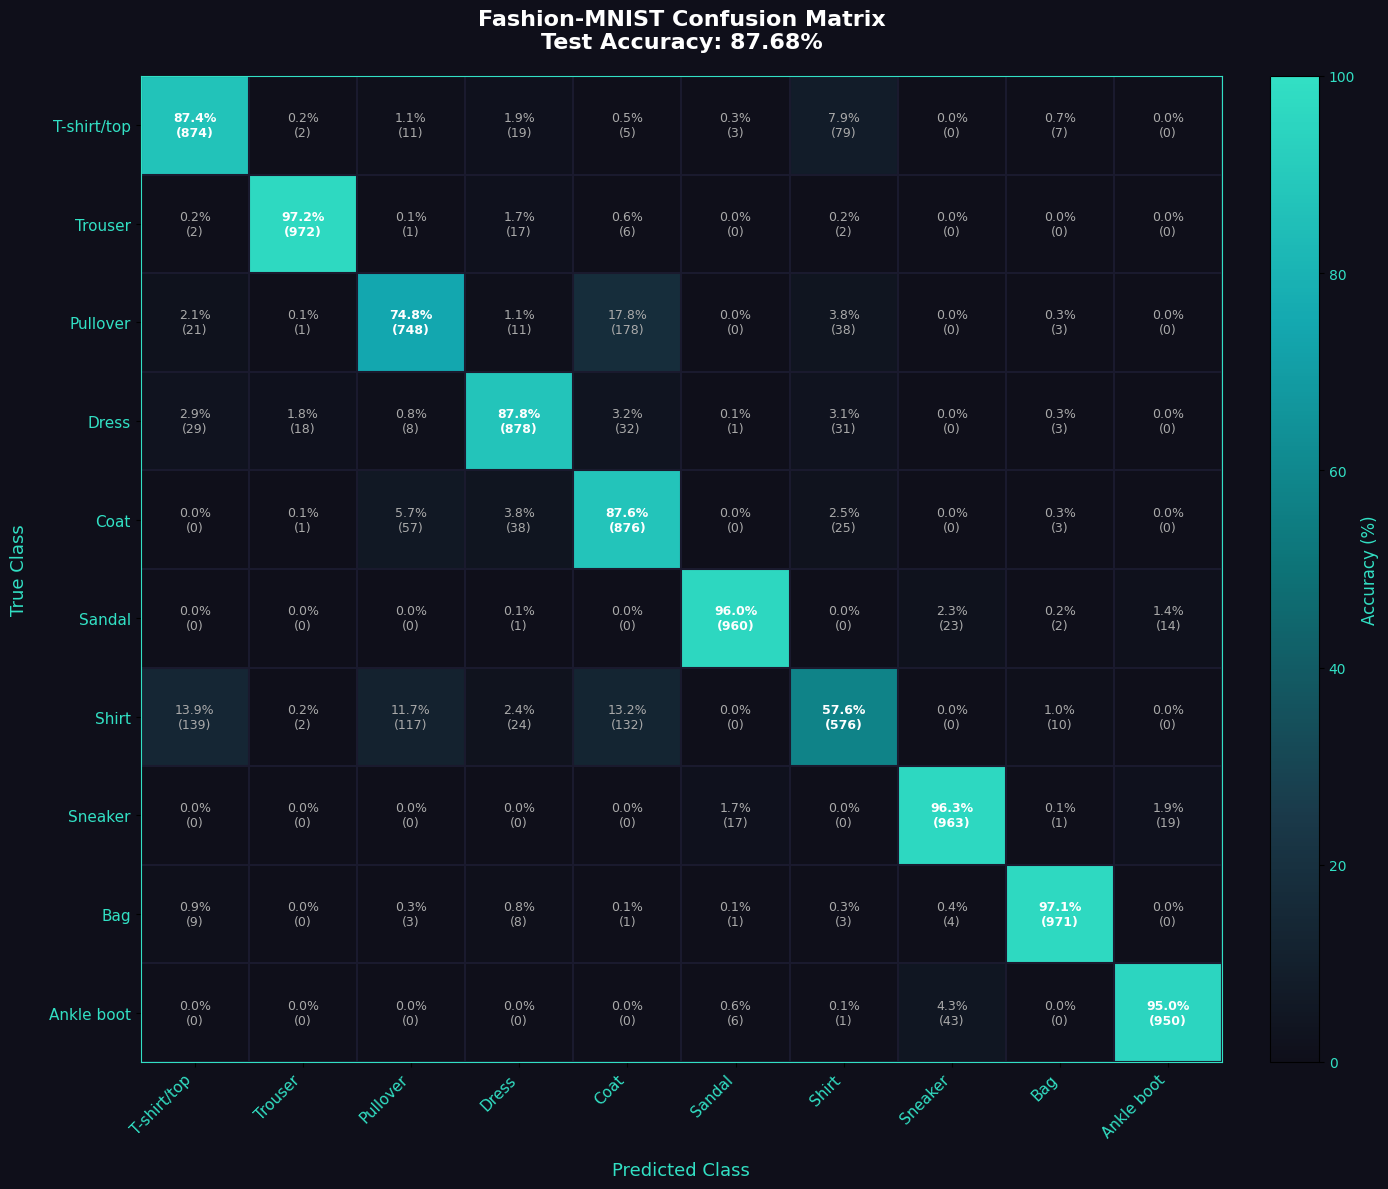

Confusion matrix generated successfully!


In [40]:
from sklearn.metrics import confusion_matrix
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import numpy as np

# Fashion-MNIST class names
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# Re-train best model configuration

np.random.seed(42)

best_parameters = initialize_parameters(
    784,
    [128, 128, 128, 128, 128],
    10,
    "xavier"
)

v, s = initialize_adam(best_parameters)

print("Training best model for confusion matrix...")

epochs = 10
batch_size = 32
learning_rate = 0.001

for epoch in range(epochs):

    num_batches = len(X_train_final) // batch_size

    for batch_idx in range(num_batches):

        start = batch_idx * batch_size
        end = start + batch_size

        X_batch = X_train_final[start:end]
        Y_batch = Y_train_final[start:end]

        # Forward propagation
        output, cache = forward_propagation(
            X_batch,
            best_parameters,
            activation="relu"
        )

        # Backpropagation
        gradients = backward_propagation(
            X_batch,
            Y_batch,
            best_parameters,
            cache,
            activation="relu"
        )

        # Adam optimizer update
        best_parameters, v, s = update_parameters_adam(
            best_parameters,
            gradients,
            v,
            s,
            t=epoch + 1,
            learning_rate=learning_rate
        )

    print(f"Epoch {epoch+1}/{epochs} completed")


# Test predictions
test_output, _ = forward_propagation(
    X_test_flat,
    best_parameters,
    activation="relu"
)

y_pred = np.argmax(test_output.T, axis=1)

y_true = y_test

# Test accuracy
test_acc = np.mean(y_pred == y_true)

print(f"\nTest Accuracy: {test_acc*100:.2f}%")

# Confusion matrix

cm = confusion_matrix(y_true, y_pred)

cm_percent = (
    cm.astype('float')
    / cm.sum(axis=1)[:, np.newaxis]
) * 100

# Creative confusion matrix plot

fig, ax = plt.subplots(figsize=(14, 12))

fig.patch.set_facecolor('#0f0f1a')

ax.set_facecolor('#0f0f1a')

# Custom color theme
colors_list = [
    '#0f0f1a',
    '#1a3a4a',
    '#0d7377',
    '#14a8b0',
    '#32e0c4'
]

custom_cmap = LinearSegmentedColormap.from_list(
    'custom',
    colors_list
)

# Heatmap
im = ax.imshow(
    cm_percent,
    cmap=custom_cmap,
    aspect='auto',
    vmin=0,
    vmax=100
)

# Cell text
for i in range(10):
    for j in range(10):

        val = cm_percent[i][j]
        count = cm[i][j]

        if i == j:
            color = 'white'
            weight = 'bold'
        else:
            color = '#aaaaaa'
            weight = 'normal'

        ax.text(
            j,
            i,
            f'{val:.1f}%\n({count})',
            ha='center',
            va='center',
            color=color,
            fontsize=9,
            fontweight=weight
        )

# Axis labels
ax.set_xticks(range(10))
ax.set_yticks(range(10))

ax.set_xticklabels(
    class_names,
    rotation=45,
    ha='right',
    fontsize=11,
    color='#32e0c4'
)

ax.set_yticklabels(
    class_names,
    fontsize=11,
    color='#32e0c4'
)

# Grid lines
ax.set_xticks(np.arange(-0.5, 10, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 10, 1), minor=True)

ax.grid(
    which='minor',
    color='#1a1a2e',
    linewidth=1.5
)

ax.tick_params(
    which='minor',
    bottom=False,
    left=False
)

# Colorbar
cbar = plt.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

cbar.set_label(
    'Accuracy (%)',
    color='#32e0c4',
    fontsize=12
)

plt.setp(
    cbar.ax.yaxis.get_ticklabels(),
    color='#32e0c4'
)

# Titles
ax.set_title(
    f'Fashion-MNIST Confusion Matrix\n'
    f'Test Accuracy: {test_acc*100:.2f}%',
    fontsize=16,
    fontweight='bold',
    color='white',
    pad=20
)

ax.set_xlabel(
    'Predicted Class',
    fontsize=13,
    color='#32e0c4',
    labelpad=15
)

ax.set_ylabel(
    'True Class',
    fontsize=13,
    color='#32e0c4',
    labelpad=15
)

# Border color
for spine in ax.spines.values():
    spine.set_edgecolor('#32e0c4')

plt.tight_layout()

plt.show()

print("Confusion matrix generated successfully!")